# BREADS MIRI Tutorial 2:  MRS High Contrast Analyses and SNR Maps using BREADS


<div class="alert alert-block alert-info">
This is the second in a series of notebooks demonstrating data reduction for MIRI using BREADS. 
    <OL><LI>Tutorial 1: Pipeline data reductions to get ready for forward modeling</LI>
        <LI>Tutorial 2 (This notebook): Forward modeling and measuring SNR of a companion</LI>
        <LI>Tutorial 3: Generating data-cube-like representations of the forward modeled data. </LI>
</div>


<div class="alert alert-block alert-warning">
Work in progress. This notebook needs more explanations and pedagogy. 
</div>


## Imports

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"        # export OMP_NUM_THREADS=1
os.environ["OPENBLAS_NUM_THREADS"] = "1"   # export OPENBLAS_NUM_THREADS=1 
os.environ["MKL_NUM_THREADS"] = "1"        # export MKL_NUM_THREADS=1
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" # export VECLIB_MAXIMUM_THREADS=1
os.environ["NUMEXPR_NUM_THREADS"] = "1"    # export NUMEXPR_NUM_THREADS=1

import numpy as np
import multiprocessing as mp
import h5py
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import lsq_linear
import glob

from breads.instruments.jwstmiri_cal import JWSTMiri_cal
from breads.grid_search import grid_search
from breads.fm.hc_atmgrid_splinefm_jwst_miri_cal import hc_atmgrid_splinefm_jwst_miri_cal
from breads.fit import fitfm
from breads.jwst_tools.flat_miri_utils import plot_flat, plot_starsub_fit
#from breads.jwst_tools.fit_miri_psf_centroid import *
from breads.jwst_tools.reduction_utils import find_files_to_process
from copy import copy

import matplotlib.pyplot as plt


In [4]:
# What does this do ???
os.environ['OBJC_DISABLE_INITIALIZE_FORK_SAFETY'] = 'YES'


In [5]:
try:
    import mkl
    mkl.set_num_threads(1)
    print("MKL has been imported")
except:
    print("MKL did not import")
    pass

MKL did not import


## Setup

In [6]:
# Number of threads to be used for multithreading
numthreads = 20

# Number of nodes
nodes = 40

## Paths

In [7]:
# Directories to update
# External_dir is where to look for external files like the btsettl grid
external_dir = './' 

# Where are the data files located? 
data_dir = "./data" 

## More Parameter Setup

In [8]:
# Definition of the wavelength sampling on which the detector images are interpolated (for each detector)
ra_offset = None
dec_offset = None

In [9]:

####################
channel = '1'
channel_reduction = '1A'
channel_band = '12A'
target_name = '* bet Pic'


In [10]:
#plot_flat(data_dir, target_name, band_list=['12A'])


## Function Definitions

In [11]:
def retrieve_data(data_dir, target_name, channel_band):
    cal_dir = os.path.join(data_dir, target_name, channel_band, 'stage2')
    print(f'Searching cal files in {cal_dir}')
    filelist = find_files_to_process(cal_dir, filetype='cal.fits')
    return filelist

def create_fm_saving_paths(data_dir, target_name, channel_band, N_nodes):
    utils_dir = os.path.join(data_dir, target_name, f'utils_fm_{N_nodes}_nodes', channel_band)
    if not os.path.exists(utils_dir):
        os.makedirs(utils_dir)
    out_dir = os.path.join(data_dir, target_name, f'fm_outputs_{N_nodes}_nodes', channel_band)
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)
    return utils_dir, out_dir

def create_miri_nodes_sampling(channel_band, N_nodes):
    if channel_band == '1A':
        x_nodes = np.linspace(4.82, 5.79, N_nodes, endpoint=True) #4.89 5.75
    elif channel_band == '2A':
        x_nodes = np.linspace(7.42, 8.82, N_nodes, endpoint=True) #7.49 8.78
    elif channel_band == '1B':
        x_nodes = np.linspace(5.61, 6.69, N_nodes, endpoint=True) #5.65 6.64
    elif channel_band == '2B':
        x_nodes = np.linspace(8.66, 10.14, N_nodes, endpoint=True)
    elif channel_band == '1C':
        x_nodes = np.linspace(6.46, 7.72, N_nodes, endpoint=True) #6.51 7.67
    elif channel_band == '2C':
        x_nodes = np.linspace(10.00, 11.712, N_nodes, endpoint=True)
    else:
        raise NotImplementedError

    return x_nodes

def interp_model_grid(grid_dir, grid_file_name, verbose=False):
    with h5py.File(os.path.join(grid_dir, grid_file_name), 'r') as hf:
        
        grid_specs = np.array(hf.get("spec"))
        grid_temps = np.array(hf.get("temps"))
        print(grid_temps)
        grid_loggs = np.array(hf.get("loggs"))
        grid_wvs = np.array(hf.get("wvs"))
        
        if verbose:
            print("[DEBUG] wavelength bounds:", np.nanmin(grid_wvs), np.nanmax(grid_wvs))
            print("[DEBUG] nan in atmospheric grid?", np.isnan(grid_specs).any())
            
    # add flux calibration correction because we are fitting a pure WebbPSF model later, which comes with systematics
    myinterpgrid = RegularGridInterpolator((grid_temps, grid_loggs), grid_specs, method="linear", bounds_error=False, fill_value=np.nan)
    #dra_comp, ddec_comp = None, None
    #fix_parameters = [teff, logg, vsini, rv, dra_comp, ddec_comp]
    return myinterpgrid, grid_wvs

## Load Cal Files

In [12]:
filelist = retrieve_data(data_dir, target_name, channel_band)

Searching cal files in ./data/* bet Pic/12A/stage2
Searching in ./data/* bet Pic/12A/stage2 for files matching jw*_cal.fits
	Found 4 input files to process
	jw01294003001_03102_00001_mirifushort_cal.fits
	jw01294003001_03102_00002_mirifushort_cal.fits
	jw01294003001_03102_00003_mirifushort_cal.fits
	jw01294003001_03102_00004_mirifushort_cal.fits


## Prepare for forward modeling: create output paths, set up node spacings

In [13]:
utils_dir, out_dir = create_fm_saving_paths(data_dir, target_name, channel_reduction, nodes)
utils_dir, out_dir

('./data/* bet Pic/utils_fm_40_nodes/1A',
 './data/* bet Pic/fm_outputs_40_nodes/1A')

In [14]:
x_nodes = create_miri_nodes_sampling(channel_reduction, nodes)
x_nodes

array([4.82      , 4.84487179, 4.86974359, 4.89461538, 4.91948718,
       4.94435897, 4.96923077, 4.99410256, 5.01897436, 5.04384615,
       5.06871795, 5.09358974, 5.11846154, 5.14333333, 5.16820513,
       5.19307692, 5.21794872, 5.24282051, 5.26769231, 5.2925641 ,
       5.3174359 , 5.34230769, 5.36717949, 5.39205128, 5.41692308,
       5.44179487, 5.46666667, 5.49153846, 5.51641026, 5.54128205,
       5.56615385, 5.59102564, 5.61589744, 5.64076923, 5.66564103,
       5.69051282, 5.71538462, 5.74025641, 5.76512821, 5.79      ])

## Main SNR analysis processing loop

### Parameters for the loop

In [15]:
read_grid = True      # Should we read in the atmosphere model file from a precomputed model grid? 
atmos_model_filename = "BT-settl_MIR.hdf5"    # What filename should be used from that grid? 

# Parameters for model grid
model_teff = 1100 # 1700
model_logg = 4.0
model_vsini = 0


# Something about applying regularization. Details TBD...
regularization_step = True
regularization = True

# Test the forward model for a fixed value of the non linear parameter.
# Make sure it does not crash and look the way you want
# THis runs the analysis for just a single position dra ddec
test = False




# Run the grid search over a parameter space to estimate planet SNR as a function of position and RV? 
# This is the main SNR output analysis.
grid_search_snr=True

# Parameters for that grid
rvs = np.array([60])                 # What RV(s) to check? 
ras = np.arange(-1.0, 1.0, 0.1)      # Delta RA for spatial sampling
decs = np.arange(-1.0, 1.0, 0.1)     # Delta Dec for spatial sampling


### Main loop

In [16]:
mypool = mp.Pool(processes=numthreads)

for i, filename in enumerate(filelist):
    print(f"\nRunning SNR analysis for {filename}   (file {i+1} of {len(filelist)})")

    preproc_task_list = []
    preproc_task_list.append(["compute_med_filt_badpix", {"window_size": 10, "mad_threshold": 20}, True, True])
    preproc_task_list.append(["compute_coordinates_arrays",])
    preproc_task_list.append(["compute_quick_webbpsf_model", {"image_mask": None, "oversample": 10}, True, True])
    preproc_task_list.append(["compute_new_coords_from_webbPSFfit", {"IWA": 0.3, "OWA": 2, "apply_offset": True}, True, True])
    preproc_task_list.append(["convert_MJy_per_sr_to_MJy"])
    #preproc_task_list.append(["apply_coords_offset", {"coords_offset": centroid}])
    #preproc_task_list.append(["compute_charge_bleeding_mask", {"threshold2mask": 0.15}])
    preproc_task_list.append(["compute_starspectrum_contnorm", {"x_nodes": x_nodes, "mppool": mypool}, True, True])
    preproc_task_list.append(["compute_starsubtraction", {"mppool": mypool}, True, True])
    
    dataobj = JWSTMiri_cal(filename, channel_reduction=channel, utils_dir=utils_dir,
                              save_utils=True, load_utils=True, preproc_task_list=preproc_task_list)

    tmp_badpixels = copy(dataobj.bad_pixels)
    subtracted_im, star_model, spline_paras, _ = dataobj.reload_starsubtraction()
    wv_sampling = np.nanmedian(dataobj.wavelengths, 1)

    if read_grid:  # read and normalize BTSettl model grid used in FM
        myinterpgrid, grid_wvs =  interp_model_grid(external_dir, atmos_model_filename)
        # #minwv, maxwv = np.min(dataobj.wavelengths), np.max(dataobj.wavelengths)
        # with h5py.File(os.path.join(external_dir, atmos_model_filename), 'r') as hf:
        #     grid_specs = np.array(hf.get("spec"))
        #     grid_temps = np.array(hf.get("temps"))
        #     grid_loggs = np.array(hf.get("loggs"))
        #     grid_wvs = np.array(hf.get("wvs"))

        # # add flux calibration correction because we are fitting a pure WebbPSF model later, which comes with systematics
        # # grid_specs = grid_specs / np.polyval(flux_calib_paras, grid_wvs)[None, None, :]

        # myinterpgrid = RegularGridInterpolator((grid_temps, grid_loggs), grid_specs, method="linear",
        #                                        bounds_error=False, fill_value=np.nan)
        # teff, logg, vsini, 
        rv, dra_comp, ddec_comp = None, None, None
        fix_parameters = [model_teff, model_logg, model_vsini, rv, dra_comp, ddec_comp]

    if regularization_step:  # Definition of the priors
        subtracted_im, star_model, spline_paras, x_nodes = dataobj.reload_starsubtraction()

        wherenan = np.where(np.isnan(spline_paras))
        reg_mean_map = copy(spline_paras)
        reg_mean_map[wherenan] = np.tile(np.nanmedian(spline_paras, axis=1)[:, None], (1, spline_paras.shape[1]))[
            wherenan]
        if regularization:
            reg_std_map = np.zeros(spline_paras.shape) + 300e-12  #np.nanmedian(spline_paras)
        else:
            reg_std_map = np.abs(spline_paras)
            reg_std_map[wherenan] = \
            np.tile(np.nanmax(np.abs(spline_paras), axis=1)[:, None], (1, spline_paras.shape[1]))[wherenan]
            reg_std_map = reg_std_map
            reg_std_map = np.clip(reg_std_map, 1e-11, np.inf)  # in MJy

    fm_paras = {"atm_grid": myinterpgrid, "atm_grid_wvs": grid_wvs, "channel":channel, "star_func": dataobj.star_func,
                "radius_as": 0.25, "badpixfraction": 0.75, "nodes": x_nodes, "fix_parameters": fix_parameters,
                "regularization": "user", "reg_mean_map": reg_mean_map,
                "reg_std_map": reg_std_map} #0.15 for 1A
    fm_func = hc_atmgrid_splinefm_jwst_miri_cal

    # /!\ Optional but recommended
    # Test the forward model for a fixed value of the non linear parameter.
    # Make sure it does not crash and look the way you want
    if test:
        # fm_paras["fix_parameters"]= [None,None,None,sc_fib]
        ra_offset, dec_offset = -0.188, 0.356 #-0.253, 0.922 #0, 0.5 #1.64, 0.50 #-0.626-0.21, -0.311-0.03 #-0.188-0.21, 0.356+0.03 #1.450, 0.490 #0.3, 0.3
        nonlin_paras = [0.0, ra_offset, dec_offset]  # rv (km/s), dra (arcsec),ddec (arcsec),

        # d is the data vector at the specified location
        # M is the linear component of the model. M is a function of the non linear parameters x,y,rv
        # s is the vector of uncertainties corresponding to d
        d, M, s, extra_outputs = fm_func(nonlin_paras, dataobj, return_extra_outputs=True, **fm_paras)
        where_finite = extra_outputs["where_trace_finite"]
        w = extra_outputs["wvs"]
        x = extra_outputs["ras"]
        y = extra_outputs["decs"]
        rows = extra_outputs["rows"]
        d_reg, s_reg = extra_outputs["regularization"]
        reg_wvs = extra_outputs["regularization_wvs"]
        reg_rows = extra_outputs["regularization_rows"]
        unique_rows = np.unique(rows)

        shifted_w = w + (wv_sampling[-1] - wv_sampling[0]) * (rows - np.nanmin(unique_rows))
        shifted_reg_wvs = reg_wvs + (wv_sampling[-1] - wv_sampling[0]) * (reg_rows - np.nanmin(unique_rows))

        validpara = np.where(np.max(np.abs(M), axis=0) != 0)
        M = M[:, validpara[0]]
        primary_hdu = fits.PrimaryHDU()

        ds = d
        Ms = M

        paras = lsq_linear(Ms, ds).x
        m = np.dot(Ms, paras)
        r = d - m

        primary_hdu = fits.PrimaryHDU()

        hdu1 = fits.ImageHDU(data=ds, name='DATA')
        hdu2 = fits.ImageHDU(data=Ms, name='MODEL_MATRIX')
        hdu3 = fits.ImageHDU(data=r, name='RESIDUALS')
        hdu4 = fits.ImageHDU(data=paras, name='LINPARAS')
        hdu5 = fits.ImageHDU(data=w, name='WAVE')
        hdu6 = fits.ImageHDU(data=s, name='NOISE')
        hdu7 = fits.ImageHDU(data=rows, name='ROWS')
        hdul = fits.HDUList([primary_hdu, hdu1, hdu2, hdu3, hdu4, hdu5, hdu6, hdu7])

        hdul.writeto(f'lsq_fit.fits', overwrite=True)


        residuals = np.ones(np.size(s) + np.size(validpara[0])) + np.nan
        residuals_H0 = np.ones(np.size(s) + np.size(validpara[0])) + np.nan
        noise4residuals = np.ones(np.size(s) + np.size(validpara[0])) + np.nan
        log_prob, log_prob_H0, rchi2, linparas, linparas_err = fitfm(nonlin_paras, dataobj, fm_func, fm_paras,
                                                                     computeH0=True, bounds=None,
                                                                     residuals=residuals, residuals_H0=residuals_H0,
                                                                     noise4residuals=noise4residuals,
                                                                     scale_noise=True,
                                                                     marginalize_noise_scaling=False)
        paras = linparas[validpara]
        print("best fit", linparas[0:5])
        print("best fit err", linparas_err[0:5])
        print("best fit snr", linparas[0:5] / linparas_err[0:5])
        print("rchi2", rchi2)

    if grid_search_snr:
        print("Grid search")
        log_prob, log_prob_H0, rchi2, linparas, linparas_err = grid_search([rvs, ras, decs], dataobj, fm_func,
                                                                           fm_paras, numthreads=numthreads,
                                                                           computeH0=False)
        outoftheoven_filename = os.path.join(out_dir,
                                             os.path.basename(filename).replace(".fits",
                                                                                "_out.hdf5"))
        print(f"==> {outoftheoven_filename}")
        with h5py.File(outoftheoven_filename, 'w') as hf:
            hf.create_dataset("rvs", data=rvs)
            hf.create_dataset("ras", data=ras)
            hf.create_dataset("decs", data=decs)
            hf.create_dataset("log_prob", data=log_prob)
            hf.create_dataset("log_prob_H0", data=log_prob_H0)
            hf.create_dataset("rchi2", data=rchi2)
            hf.create_dataset("linparas", data=linparas)
            hf.create_dataset("linparas_err", data=linparas_err)

mypool.close()
mypool.join()


Running SNR analysis for ./data/* bet Pic/12A/stage2/jw01294003001_03102_00001_mirifushort_cal.fits   (file 1 of 4)
Reading data from ./data/* bet Pic/12A/stage2/jw01294003001_03102_00001_mirifushort_cal.fits
Photom file selected: jwst_miri_photom_0224.fits
Photom file selected: jwst_miri_photom_0210.fits
Wavelength map loaded
	Unpacking data quality bitmasks. DQ array is of type uint32
Loading data for compute_med_filt_badpix cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00001_mirifushort_cal_roughbadpix.fits
Loading data for compute_coordinates_arrays cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00001_mirifushort_cal_relcoords.fits
Loading data for compute_quick_webbpsf_model cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_mirifushort_quick_webbpsf.fits
Loading data for compute_new_coords_from_webbPSFfit cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00001_mirifushort_cal_newcen_wpsf.fits
Running c

/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/var/folders/wj/p62fp78j0z1b4xyr2yql1prw00042w/T/ipykernel_68249/624996590.py:47: RuntimeWarning: All-NaN slice encountered
  reg_mean_map[wherenan] = np.tile(np.nanmedian(spline_paras, axis=1)[:, None], (1, spline_paras.shape[1]))[
/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)
/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources i

==> ./data/* bet Pic/fm_outputs_40_nodes/1A/jw01294003001_03102_00001_mirifushort_cal_out.hdf5

Running SNR analysis for ./data/* bet Pic/12A/stage2/jw01294003001_03102_00002_mirifushort_cal.fits   (file 2 of 4)
Reading data from ./data/* bet Pic/12A/stage2/jw01294003001_03102_00002_mirifushort_cal.fits
Photom file selected: jwst_miri_photom_0224.fits
Photom file selected: jwst_miri_photom_0210.fits
Wavelength map loaded
	Unpacking data quality bitmasks. DQ array is of type uint32
Loading data for compute_med_filt_badpix cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00002_mirifushort_cal_roughbadpix.fits
Loading data for compute_coordinates_arrays cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00002_mirifushort_cal_relcoords.fits
Loading data for compute_quick_webbpsf_model cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_mirifushort_quick_webbpsf.fits
Loading data for compute_new_coords_from_webbPSFfit cached in ./data/* be

/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)
/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)
/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en

==> ./data/* bet Pic/fm_outputs_40_nodes/1A/jw01294003001_03102_00002_mirifushort_cal_out.hdf5

Running SNR analysis for ./data/* bet Pic/12A/stage2/jw01294003001_03102_00003_mirifushort_cal.fits   (file 3 of 4)
Reading data from ./data/* bet Pic/12A/stage2/jw01294003001_03102_00003_mirifushort_cal.fits
Photom file selected: jwst_miri_photom_0224.fits
Photom file selected: jwst_miri_photom_0210.fits
Wavelength map loaded
	Unpacking data quality bitmasks. DQ array is of type uint32
Loading data for compute_med_filt_badpix cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00003_mirifushort_cal_roughbadpix.fits
Loading data for compute_coordinates_arrays cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00003_mirifushort_cal_relcoords.fits
Loading data for compute_quick_webbpsf_model cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_mirifushort_quick_webbpsf.fits
Loading data for compute_new_coords_from_webbPSFfit cached in ./data/* be

/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)
/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)
/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en

==> ./data/* bet Pic/fm_outputs_40_nodes/1A/jw01294003001_03102_00003_mirifushort_cal_out.hdf5

Running SNR analysis for ./data/* bet Pic/12A/stage2/jw01294003001_03102_00004_mirifushort_cal.fits   (file 4 of 4)
Reading data from ./data/* bet Pic/12A/stage2/jw01294003001_03102_00004_mirifushort_cal.fits
Photom file selected: jwst_miri_photom_0224.fits
Photom file selected: jwst_miri_photom_0210.fits
Wavelength map loaded
	Unpacking data quality bitmasks. DQ array is of type uint32
Loading data for compute_med_filt_badpix cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00004_mirifushort_cal_roughbadpix.fits
Loading data for compute_coordinates_arrays cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00004_mirifushort_cal_relcoords.fits
Loading data for compute_quick_webbpsf_model cached in ./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_mirifushort_quick_webbpsf.fits
Loading data for compute_new_coords_from_webbPSFfit cached in ./data/* be

/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)
/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)
/Users/mperrin/miniconda3/envs/stenv-py3.12-2025.07.16/lib/python3.12/site-packages/stsci/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en

==> ./data/* bet Pic/fm_outputs_40_nodes/1A/jw01294003001_03102_00004_mirifushort_cal_out.hdf5


The outputs are a bunch of HDF5 files: 

In [17]:
glob.glob(os.path.join(data_dir, target_name,  f"fm_outputs_{nodes}_nodes", channel_reduction, "*.*"))

['./data/* bet Pic/fm_outputs_40_nodes/1A/jw01294003001_03102_00002_mirifushort_cal_out.hdf5',
 './data/* bet Pic/fm_outputs_40_nodes/1A/jw01294003001_03102_00003_mirifushort_cal_out.hdf5',
 './data/* bet Pic/fm_outputs_40_nodes/1A/jw01294003001_03102_00001_mirifushort_cal_out.hdf5',
 './data/* bet Pic/fm_outputs_40_nodes/1A/jw01294003001_03102_00004_mirifushort_cal_out.hdf5']

As is standard for BREADS, the intermediate data products are all saved in a so-called "utils" subdirectory:

In [18]:
fns = glob.glob(os.path.join(data_dir, target_name,  f"utils_fm_{nodes}_nodes", channel_reduction, "*.*"))
fns.sort()
fns

['./data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00001_mirifushort_cal_newcen_wpsf.fits',
 './data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00001_mirifushort_cal_relcoords.fits',
 './data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00001_mirifushort_cal_roughbadpix.fits',
 './data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00001_mirifushort_cal_starspec_contnorm.fits',
 './data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00001_mirifushort_cal_starsub.fits',
 './data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00002_mirifushort_cal_newcen_wpsf.fits',
 './data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00002_mirifushort_cal_relcoords.fits',
 './data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00002_mirifushort_cal_roughbadpix.fits',
 './data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00002_mirifushort_cal_starspec_contnorm.fits',
 './data/* bet Pic/utils_fm_40_nodes/1A/jw01294003001_03102_00002_mirifushort_cal_stars

## Plot Outputs

Alexis says: Basically we take a look at the linparas output where the first term of the vector is the scaling flux of the tested template and we make the ratio with the first term of linparas_err to get the SNR

In [19]:
companion_offsets = [[0.2828, 0.4603],   # [dRA, dDec] for each companion.
                                        # Values taken from whereistheplanet.org for the date of observation.
                     ]

/Users/mperrin/Dropbox (Personal)/Documents/software/git/breads/breads/jwst_tools/open_fm_outputs.py:148: RuntimeWarning: invalid value encountered in divide
  snr_map = (flux_p[index, k] / flux_error[index, k]).T


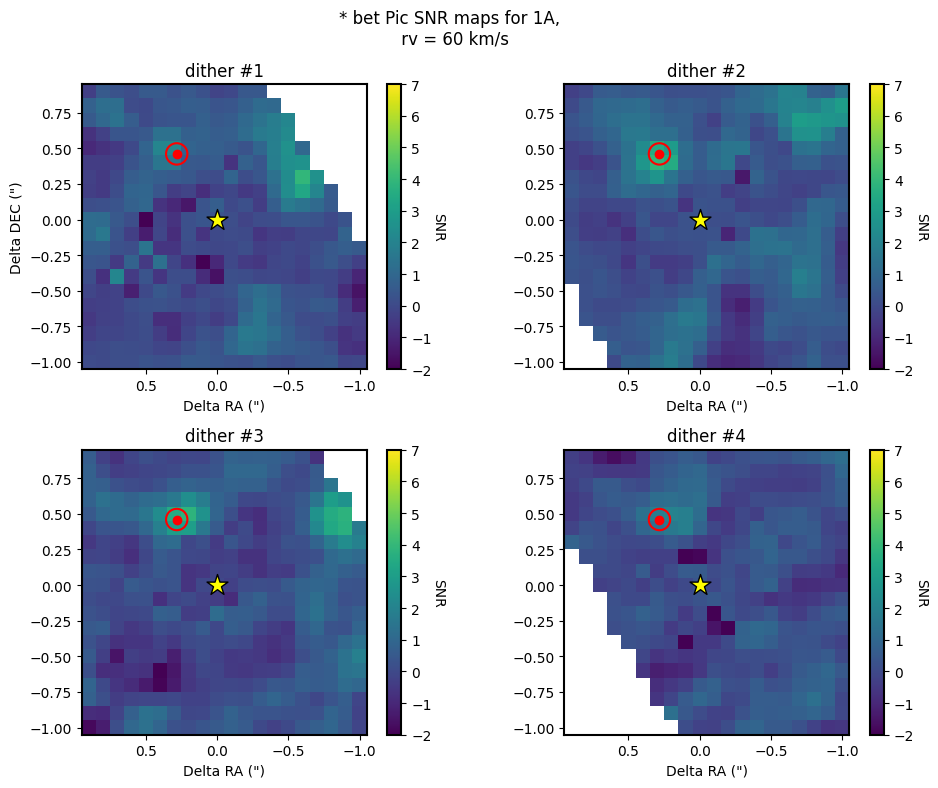

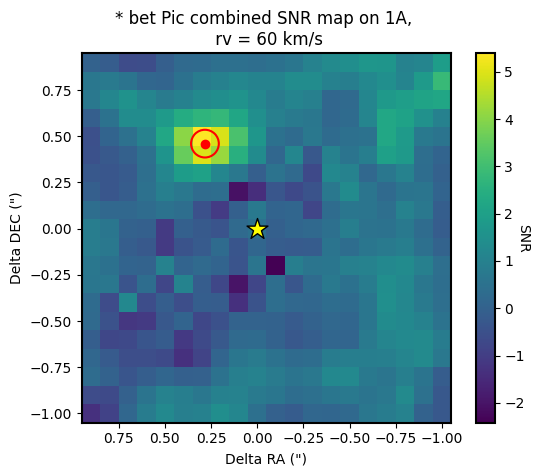

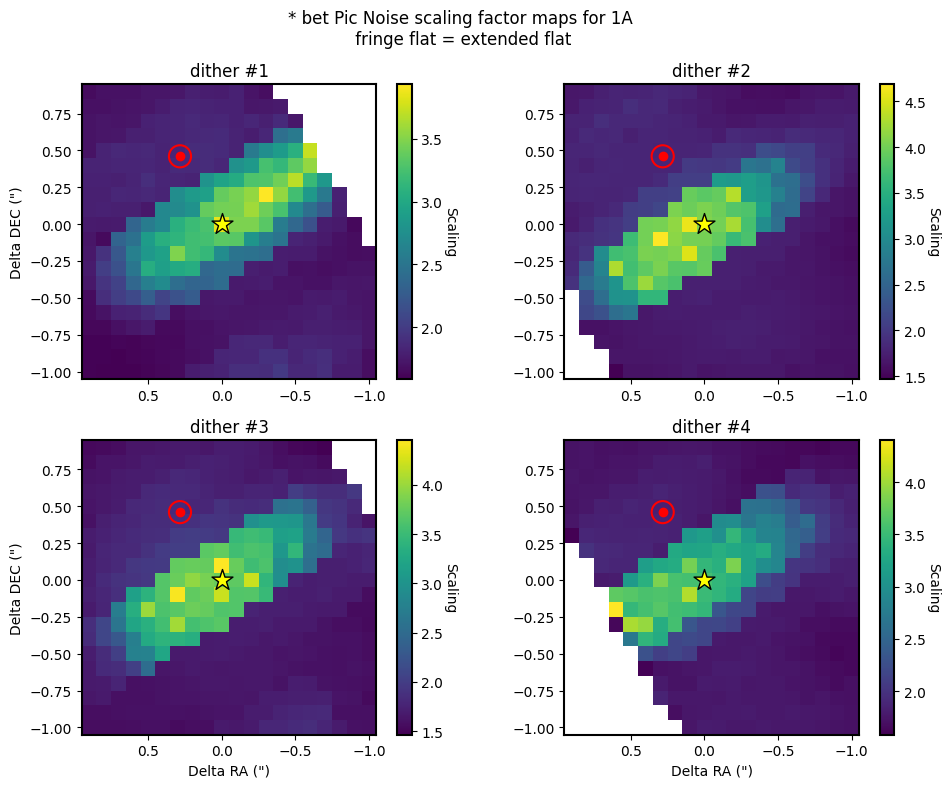

In [20]:
%matplotlib inline
from breads.jwst_tools.open_fm_outputs import *
import matplotlib


open_fm_outputs_miri(data_dir, target_name, nodes, list_bands=['1A'], companion_offsets=companion_offsets)

    #plot_combined_hf_starspectrum("/Users/abidot/Desktop/miri_data_4829_new/", "HD 218396", 160, list_bands=['3B'])
    #coor_ptheta = [[2, 2.5|]]

    #open_fm_outputs_miri("/Users/abidot/Desktop/miri_data_8714_gitest/", "* eps Ind Ab", 85, list_bands=['2A'], coor_ptheta=coor_ptheta)
    #plot_combined_hf_starspectrum("/Users/abidot/Desktop/miri_data_8714_gitest/", '* eps Ind Ab', 85, list_bands=['1A'])